# Transfer Learning, Spec-Driven: From Pretraining to Deployment

**Goal.** Teach, end-to-end, the transfer learning workflow: reuse a pretrained
ResNet18 and adapt it to a small, imbalanced 2-class manufacturing-defect task,
comparing five adaptation strategies. Everything runs on CPU and is fully
self-contained.

---

## Section 1 — Introduction

**Objective.** Explain **why transfer learning exists** before how it works:
training modern deep CNNs from scratch demands enormous datasets, extensive
computational resources and long training times; transfer learning reuses
previously learned knowledge instead. The goal block above already framed the
problem; this section anchors the motivation that follows.

---

## Section 2 — Motivation

Training a deep CNN **from scratch** needs:

- **enormous datasets** (millions of labeled images),
- **extensive computational resources** (GPU-days),
- **long training times**.

Separately, defect detection hardly ever has a million labeled images. So we
reuse knowledge instead of re-learning vision from zero:

```text
Large Dataset  →  Pretrained Model  →  Reuse Knowledge  →  Target Problem
```

**Everyday analogy — car 🚗 → truck 🚚.** You don't re-learn how a steering wheel,
pedals or mirrors work when you switch from a car to a truck. The *general driving
skills* transfer; you only adapt to the new vehicle (bigger blind spots, different
braking). Transfer learning is exactly that: the network already *knows how to
see*; we only teach it the specifics of *our* problem.

### Benefits of transfer learning
- **Lower computational cost** — we train far fewer parameters.
- **Less labeled data required** — hundreds of images can be enough.
- **Faster convergence** — we start from a useful representation, not noise.
- **Often better performance** — the pretrained features are a strong prior.

---

## Roadmap

We follow this mandatory conceptual sequence. Each major section ends with a
short **takeaway**; each implementation is introduced *after* its concept and
interpreted *after* it runs (before / during / after coding discipline).

```text
Motivation → Definition → Assumptions → Pretraining → Source Task
→ Target Task → Feature Reuse → Network Modification → Freeze Layers
→ Fine-Tuning (partial AND full) → PEFT → Task Relatedness → Experiments
→ Conclusions
```


In [ ]:
# === Setup & Framing ==========================================================
# Load every dependency ONCE, set a fixed SEED, pick a CPU-safe device, start a
# wall-clock timer for the measured-cost report, and import OPTIONAL libraries
# with graceful fallbacks so the notebook runs even when they are missing.

# --- Plot backend: render figures inline in the notebook --------------------
%matplotlib inline

import os
import sys
import json
import copy
import glob
import math
import time
import random
import shutil
import warnings
import zipfile
import urllib.request
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Callable     # noqa: F401

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights    # current weights API

from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

import matplotlib as _mpl  # imported to keep name `pyplot` short; no-op here

# --- Device: CPU-safe default ----------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE} | torch threads: {torch.get_num_threads()}")
if DEVICE.type == "cpu":
    print("[CPU] Training will be slower. We use a REDUCED epoch budget and an "
          "explicit memory-over-speed trade-off (see Section 13).")

# --- Reproducibility ------------------------------------------------------------
SEED = 42

def set_seed(seed: int = SEED) -> None:
    """Reset every random source so each variant starts identically (NFR-3)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed()

# --- Optional: psutil for peak-RSS measurement (fallback 0.0) --------------------
try:
    import psutil
    PSUTIL_AVAILABLE = True
except ImportError:
    PSUTIL_AVAILABLE = False
    warnings.warn("`psutil` unavailable; peak-RSS will be reported as 0.0.")

# --- Optional: peft for LoRA (fallback = manual LoRA) ----------------------------
MIN_PEFT_VERSION = (0, 16, 0)
try:
    import peft
    from peft import LoraConfig, get_peft_model
    _v = tuple(int(x) for x in peft.__version__.split(".")[:3] if x.isdigit())
    if _v < MIN_PEFT_VERSION:
        raise ImportError(f"peft {peft.__version__} < {MIN_PEFT_VERSION}")
    PEFT_AVAILABLE = True
except Exception as _e:                                       # noqa: BLE001
    PEFT_AVAILABLE = False
    warnings.warn(f"peft unavailable ({_e}); using the manual LoRA fallback.")
# Also verify torchao (peft runtime dependency) is compatible
if PEFT_AVAILABLE:
    try:
        import torchao
    except ImportError:
        pass                                                  # not installed = fine
    else:
        _tao = tuple(int(x) for x in torchao.__version__.split(".")[:3] if x.isdigit())
        if _tao < (0, 16, 0):
            PEFT_AVAILABLE = False
            warnings.warn(f"torchao {torchao.__version__} incompatible with peft; "
                          "using the manual LoRA fallback.")


# --- Optional: ipywidgets for the interactive experiment --------------------------
try:
    import ipywidgets as widgets
    from IPython.display import display
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False
    warnings.warn("ipywidgets missing; interactive experiment falls back to a "
                  "plain call.")

# --- Global constants + wall-clock -----------------------------------------------
NUM_CLASSES = 2
CLASS_NAMES = ["normal", "defective"]      # index 0 = majority class
SHOW_SOLUTIONS = True                      # reveal the "Your Turn" solutions
START_WALL = time.perf_counter()           # total wall-clock for cost report
print(f"[setup] done. peft={PEFT_AVAILABLE}, psutil={PSUTIL_AVAILABLE}, "
      f"widgets={WIDGETS_AVAILABLE}")


Device: cpu | torch threads: 2
[CPU] Training will be slower. We use a REDUCED epoch budget and an explicit memory-over-speed trade-off (see Section 13).
[setup] done. peft=True, psutil=True, widgets=True


## Section 3 — Formal Definition

We need precise words before code. In transfer learning we always distinguish a
**source** and a **target**:

| Concept | Meaning |
|---|---|
| **Domain** | The feature space $\mathcal{X}$ and the probability distribution $P(X)$ over it. |
| **Task** | The label space $\mathcal{Y}$ and the predictive function $f: \mathcal{X} \to \mathcal{Y}$. |
| **Source** ($\mathcal{D}_s$, $\mathcal{T}_s$) | Where knowledge comes from (e.g. ImageNet classification). |
| **Target** ($\mathcal{D}_t$, $\mathcal{T}_t$) | Where knowledge is applied (our defect task). |

Transfer learning applies when

- $D_s \neq D_t$ (different feature space *or* different data distribution), and
- $T_s \neq T_t$ (different labels *or* different predictive function).

### Visual diagram

```text
Source Dataset → Source Task → Learned Representation → Transfer
→ Target Dataset → Target Task
```

The **learned representation** is what crosses the gap — not the raw predictions.

**Takeaway — §3:** Transfer learning reuses a learned *representation* built for a
source problem and applies it to a different target problem.


## Section 4 — Assumptions of Transfer Learning

Transfer learning works only when three assumptions hold. Each has its own
subsection.

### 4.1 Feature Transferability

Deep CNNs learn features **hierarchically**:

```text
Edges → Textures → Shapes → Object Parts → Semantic Objects
```

- **Lower layers** are more *general*: edges and textures appear in almost any
  image, so they transfer broadly.
- **Higher layers** are more *specific*: semantic objects depend on the dataset.

Transfer learning primarily reuses **learned representations**, not labels.

### 4.2 Data Asymmetry

The realistic setting: a **large source dataset** and a **small target dataset**.
Target labels are scarce because annotation is limited, expensive, and slow — so
we want the pretrained model to do most of the heavy lifting.

### 4.3 Task Relatedness

Transfer assumes the source and target share useful structure:
- **Good transfer:** dogs → wolves, cars → trucks, flowers → plants.
- **Poor transfer:** ImageNet → MRI scans, flowers → satellite imagery.

When the tasks are unrelated, applying source knowledge can **hurt** — this is
**negative transfer**: the target performs *worse* than training from scratch.

**Takeaway — §4:** Transfer is not always beneficial. Feature transferability,
data asymmetry and task relatedness determine whether it helps.


## Section 5 — The Complete Transfer Learning Workflow

Before any code, here is the whole pipeline. Each of the next sections maps to
exactly one stage:

```text
Pretraining
     ↓
Pretrained Model
     ↓
Feature Reuse
     ↓
Network Modification
     ↓
Freeze Layers
     ↓
Fine-Tuning
     ↓
Evaluation
```

| Stage | Notebook section |
|---|---|
| Pretraining | §6 — where the pretrained knowledge comes from |
| Pretrained Model | §7 + code — load ResNet18 with ImageNet weights |
| Feature Reuse | §9 — visualize what actually transfers |
| Network Modification | §10 — replace the 1000-class head |
| Freeze Layers | §11 — freeze the backbone, train only the head |
| Fine-Tuning | §12 — partial and full unfreeze |
| Evaluation | §13–16 — 5-strategy comparison |

**Takeaway — §5:** Keep this diagram in mind; each following section is one step
on this path from pretraining to evaluation.


## Section 6 — Pretraining (Knowledge Acquisition)

### Option A — Use an existing pretrained model (this notebook)

Public models trained on ImageNet: **ResNet**, **EfficientNet**, **MobileNet**,
**Vision Transformer (ViT)**. We download their weights and reuse them — no
pretraining cost for us.

### Option B — Train your own source model

Industrial scenario: train on a **large proprietary dataset**

```text
Large proprietary dataset → Source Model → Future downstream tasks
```

This notebook focuses on **Option A** (ResNet18 pretrained on ImageNet).

**Takeaway — §6:** Pretrained knowledge comes either from public models (our
approach) or from in-house source models. Both give us a reusable feature
extractor.


## Section 7 — Source Task: What the Pretrained Model Learned

The source task of our pretrained ResNet18 is **ImageNet-1k**:

- **Dataset:** ~1.28 million natural images.
- **Task:** 1000-class image classification (dogs, cars, fish, tools, ...).

### Key question: what did the model actually learn?

**Not the labels. Not the classes.** It learned **useful feature representations**
— a hierarchy of filters that convert raw pixels into increasingly abstract
descriptions of visual content.

Those representations are the transferable asset. The 1000-way classifier on top
is just a "head" that maps representations to ImageNet classes — and it is the
first thing we will discard.

**Takeaway — §7:** Pretraining teaches *how to see*, not *what the classes are*.
We reuse the vision, not the 1000-class mapping.


In [ ]:
# === Before Coding ==============================================================
# What: load ResNet18 with the CURRENT weights API and inspect its architecture.
# Why:  we need to see the exact module structure (resnet.fc is the 1000-class
#       head; the conv body is the feature extractor) before we modify it.
# Expected: ~11.7M parameters, final layer fc (1000 classes).
# --------------------------------------------------------------------------------
# Current API: weights=ResNet18_Weights.DEFAULT. The legacy `pretrained=True`
# argument is deprecated and MUST NOT be used.
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
model.to(DEVICE)

print("Top-level children:")
for name, child in model.named_children():
    print(f"  {name:<10s} -> {type(child).__name__}")

print("\nFirst parameters (shape, requires_grad):")
for name, p in list(model.named_parameters())[:6]:
    print(f"  {name:<26s} shape={tuple(p.shape)} requires_grad={p.requires_grad}")

n_total = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal params: {n_total:,} | Trainable params: {n_trainable:,}")
print(f"Head: {model.fc}")   # this is the 1000-way ImageNet classifier


Top-level children:
  conv1      -> Conv2d
  bn1        -> BatchNorm2d
  relu       -> ReLU
  maxpool    -> MaxPool2d
  layer1     -> Sequential
  layer2     -> Sequential
  layer3     -> Sequential
  layer4     -> Sequential
  avgpool    -> AdaptiveAvgPool2d
  fc         -> Linear

First parameters (shape, requires_grad):
  conv1.weight               shape=(64, 3, 7, 7) requires_grad=True
  bn1.weight                 shape=(64,) requires_grad=True
  bn1.bias                   shape=(64,) requires_grad=True
  layer1.0.conv1.weight      shape=(64, 64, 3, 3) requires_grad=True
  layer1.0.bn1.weight        shape=(64,) requires_grad=True
  layer1.0.bn1.bias          shape=(64,) requires_grad=True

Total params: 11,689,512 | Trainable params: 11,689,512
Head: Linear(in_features=512, out_features=1000, bias=True)


## Section 8 — Target Task

Our new problem: **manufacturing defect detection** with a small, imbalanced
image dataset. Layout:

```text
data_transfer_learning/
├── train/  normal/ defective/
└── val/    normal/ defective/
```

- **2 classes:** `normal` and `defective`.
- **Imbalanced ≈ 80/20** (few defective samples — the minority we care most about).
- **Real photographic images** (Hyn/Hymenoptera photos), resized to 224×224.

### Source vs. Target

| Property | Source (ImageNet) | Target (defects) |
|---|---|---|
| Samples | Millions | Hundreds |
| Task | General 1000-class | Specific 2-class |
| Dataset size | Large | Small |
| Class balance | Roughly balanced | 80/20 imbalanced |
| Head | 1000-way | 2-way |
| Domain | Everyday objects | Manufacturing surface inspection |

### Why transfer is advantageous here

- Hundreds of images are far too few to train a deep CNN from scratch.
- ImageNet's early features (edges, textures) are exactly what surface inspection
  needs.
- The domain is *moderately* related (natural-ish RGB photos), so most of the
  feature extractor is reusable.

**Takeaway — §8:** A small, imbalanced target is the textbook scenario for
transfer learning: the source supplies the visual machinery; the target only
needs a thin adaptation.


In [ ]:
# === Before Coding ==============================================================
# What: resolve the dataset root RELATIVE to the notebook, and if the required
#       train/{normal,defective} + val/{normal,defective} folders are missing or
#       EMPTY, auto-download REAL Hyn/Hymenoptera photos and split them 80/20.
# Why:  FR-23 — the notebook must run standalone on a fresh machine; real images
#       are required (no dummy numpy/colour blocks), and EXISTING files are never
#       overwritten.
# Expected: DATA_DIR points to a folder with the 4 class folders; if they were
#       empty it now holds real photos.
# --------------------------------------------------------------------------------

# Resolve relative to the notebook directory. Kernels run with cwd == the folder
# that holds the notebook (nbs/finetunning/), so "sibling" is ../data_transfer_learning.
NOTEBOOK_DIR = Path.cwd()

# Candidate list, ENDING at the sibling ../data_transfer_learning (locked).
_CANDIDATES = [
    NOTEBOOK_DIR / "data_transfer_learning",
    NOTEBOOK_DIR / "data",
    NOTEBOOK_DIR / "data/defects",
    NOTEBOOK_DIR.parent / "data_transfer_learning",        # <-- sibling required
]


def _class_dirs_exist(root: Path) -> bool:
    """True when all four class folders exist (may still be empty)."""
    return all((root / "train" / c).is_dir() and (root / "val" / c).is_dir()
               for c in CLASS_NAMES)


def _is_populated(root: Path) -> bool:
    """True when every class folder contains at least one image file."""
    if not _class_dirs_exist(root):
        return False
    for c in CLASS_NAMES:
        for split in ("train", "val"):
            files = list((root / split / c).glob("*"))
            if not files:
                return False
    return True


# Pick the first usable candidate (prefers real populated data).
DATA_DIR = None
for _cand in _CANDIDATES:
    if _cand.is_dir() and _is_populated(_cand):
        DATA_DIR = _cand
        break

# Fallback: create the sibling and download real images into it.
if DATA_DIR is None:
    DATA_DIR = NOTEBOOK_DIR.parent / "data_transfer_learning"
    DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset root: {DATA_DIR.resolve()}")


def _redistribute_8020(ants_dir, bees_dir, dest_normal, dest_defective):
    """
    Copies images into dest_normal / dest_defective to create an 80/20 split.
    ALL ants go to normal; a random 20% subset of bees goes to defective.
    Returns the total number of files copied.
    """
    dest_normal.mkdir(parents=True, exist_ok=True)
    dest_defective.mkdir(parents=True, exist_ok=True)

    ant_imgs = sorted(p for p in ants_dir.glob("*")
                      if p.suffix.lower() in (".jpg", ".jpeg", ".png"))
    bee_imgs = sorted(p for p in bees_dir.glob("*")
                      if p.suffix.lower() in (".jpg", ".jpeg", ".png"))

    for p in ant_imgs:
        shutil.copy2(str(p), str(dest_normal / p.name))

    target_defective_count = max(1, int(len(ant_imgs) * 0.25))
    target_defective_count = min(target_defective_count, len(bee_imgs))
    bee_pool = bee_imgs.copy()
    random.shuffle(bee_pool)
    for p in bee_pool[:target_defective_count]:
        shutil.copy2(str(p), str(dest_defective / p.name))

    n_normal = len(ant_imgs)
    n_defective = min(target_defective_count, len(bee_imgs))
    total = n_normal + n_defective
    print(f"Dataset Split -> Normal: {n_normal} ({n_normal/total:.0%}) | Defective: {n_defective} ({n_defective/total:.0%})")
    return total


def _ensure_dataset(root: Path) -> None:
    """Download REAL Hyn/Hymenoptera photos ONLY when the class folders are empty.
    The download is wrapped in try/except so an offline machine NEVER crashes."""
    if _is_populated(root):
        print("[dataset] Real images already present; nothing to download.")
        return

    print("[dataset] Class folders are missing or empty. Downloading real "
          "Hyn/Hymenoptera photos (80/20 split)...")
    # [VERIFIED] — canonical PyTorch tutorial dataset (hymenoptera_data.zip).
    # Guarded so an offline machine never crashes; existing images are never overwritten.
    url = "https://download.pytorch.org/tutorial/hymenoptera_data.zip"
    try:
        zip_path = root / "hymenoptera_data.zip"
        urllib.request.urlretrieve(url, str(zip_path))
        extract_dir = root / "hymenoptera_extracted"
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(str(extract_dir))
        zip_path.unlink(missing_ok=True)

        train_src = extract_dir / "hymenoptera_data" / "train"
        val_src = extract_dir / "hymenoptera_data" / "val"
        n_train = _redistribute_8020(train_src / "ants", train_src / "bees",
                                     root / "train" / "normal",
                                     root / "train" / "defective")
        n_val = _redistribute_8020(val_src / "ants", val_src / "bees",
                                   root / "val" / "normal",
                                   root / "val" / "defective")
        shutil.rmtree(extract_dir, ignore_errors=True)
        print(f"[dataset] Done: {n_train} train + {n_val} val images (80/20).")
    except Exception as e:                                    # noqa: BLE001
        print(f"[dataset] Auto-download failed (offline or URL unreachable): {e}")
        print("[dataset] Continue is safe: downstream cells raise a clear error "
              "only if the folders are still empty.")

_ensure_dataset(DATA_DIR)


Dataset root: /home/lnxmacreat/wsp/projects/agents/forge-auditAgent/reference/research/ADWs/fineTunningEnv/nbs/data_transfer_learning
[dataset] Real images already present; nothing to download.


In [ ]:
# === Before Coding ==============================================================
# What: a custom ImageFolderDataset + aggressive train transforms / minimal val
#       transforms, then class counts and inverse-frequency class weights.
# Why:  FR-21 — the dataset is ~80/20 imbalanced; we need per-class counts to
#       weight the loss so the minority class is not ignored.
# Expected: train ~400 / val ~96 images with counts printed per class.
# --------------------------------------------------------------------------------

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]     # the statistics pretrained weights expect
IMAGENET_STD = [0.229, 0.224, 0.225]


class ImageFolderDataset(Dataset):
    """Minimal ImageFolder-style dataset over the two-class structure."""

    def __init__(self, root: Path, split: str, transform=None):
        self.transform = transform
        self.samples = []                                   # list of (path, label)
        for label, cls in enumerate(CLASS_NAMES):
            cls_dir = root / split / cls
            for f in sorted(cls_dir.glob("*")):
                if f.suffix.lower() in (".jpg", ".jpeg", ".png"):
                    self.samples.append((f, label))

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")               # always 3-channel
        if self.transform is not None:
            img = self.transform(img)
        return img, label


# Aggressive train transforms (more augmentation = more diversity on 400 images);
# minimal val transforms (no augmentation = honest validation numbers).
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_ds = ImageFolderDataset(DATA_DIR, "train", transform=train_transforms)
val_ds = ImageFolderDataset(DATA_DIR, "val", transform=val_transforms)

assert len(train_ds) > 0 and len(val_ds) > 0, \
    "Empty split — check the dataset layout (see the previous cell)."

print(f"train: {len(train_ds)} images | val: {len(val_ds)} images")
for split, ds in [("train", train_ds), ("val", val_ds)]:
    counts = np.bincount([lbl for _, lbl in ds.samples], minlength=NUM_CLASSES)
    fracs = counts / counts.sum()
    detail = ", ".join(f"{CLASS_NAMES[i]}={counts[i]} ({fracs[i]:.0%})"
                       for i in range(NUM_CLASSES))
    print(f"  {split:5s} -> {detail}")


train: 400 images | val: 96 images
  train -> normal=320 (80%), defective=80 (20%)
  val   -> normal=76 (79%), defective=20 (21%)


In [ ]:
# === Class-imbalance handling: inverse-frequency weights + sampler ==============
# FR-21. With an ~80/20 split a naive CrossEntropyLoss is dominated by the
# majority class. We do two things:
#   (1) weight the loss by inverse class frequency,
#   (2) oversample the minority class with a WeightedRandomSampler.

# Inverse-frequency class weights, normalized.
labels = [lbl for _, lbl in train_ds.samples]
class_counts = np.bincount(labels, minlength=NUM_CLASSES)
class_weights = 1.0 / np.maximum(class_counts, 1)          # inverse frequency
class_weights /= class_weights.sum()                        # normalized

# Per-sample weights feed the sampler -> minority samples seen more often.
sample_weights = class_weights[labels]
sampler = WeightedRandomSampler(sample_weights,
                                num_samples=len(sample_weights),
                                replacement=True)

# Loss is NOT re-weighted: WeightedRandomSampler already balances the classes
# during sampling, so re-weighting the loss too would double-compensate.
criterion = nn.CrossEntropyLoss()

print("Class counts (train):", dict(zip(CLASS_NAMES, class_counts)))
print("Inverse-frequency weights:", class_weights)

# CPU-friendly budget: small batch, single worker -> bounded memory. Declared
# here because every later cell reads BATCH_SIZE (FR-24).
BATCH_SIZE = 8

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
print("Loaders ready. (WeightedRandomSampler oversamples the minority class.)")


## Section 9 — Feature Reuse

The **core idea of transfer learning**: we reuse *learned representations*, not
predictions.

```text
Input Image → Feature Extractor → Feature Vector → Classifier
```

- The **feature extractor** (conv network) is the reusable, valuable part.
- The **classifier** (head) is the only piece that changes.

To make this concrete we hook **forward activations** from an early layer
(`layer1`) and a late layer (`layer4`) on one target image and visualize them.

- **Early layers** detect generic edges and textures → transfer well.
- **Late layers** detect task-specific semantics → often re-learned or frozen.

**Before coding:** we will register forward hooks, run one forward pass in
`torch.inference_mode()`, and plot channel maps. Expected: early maps look like
dense edge/texture detectors; late maps are sparser and more task-specific.

**Takeaway — §9:** What transfers is the feature extractor; the classifier is
cheap to replace and retrain.


In [ ]:
# === During Coding: visualize early vs late activations (FR-9) ==================
# Why we hook named children: to grab activations from the conv body directly.
# Why we use torch.inference_mode: activation inspection, no autograd needed.

def get_activation_maps(model, image_tensor, layer_names=("layer1", "layer4")):
    """Return {layer_name: activation tensor} by hooking named children."""
    activations: Dict[str, torch.Tensor] = {}
    hooks = []
    for name in layer_names:
        layer = dict(model.named_children())[name]
        hooks.append(layer.register_forward_hook(
            lambda mod, inp, out, _n=name: activations.__setitem__(
                _n, out.detach().cpu())))
    model.eval()
    with torch.inference_mode():
        model(image_tensor.unsqueeze(0).to(DEVICE))
    for h in hooks:
        h.remove()
    return activations


# Preview transform: resize + tensor + normalize (matches the ImageNet stats
# the pretrained ResNet18 expects; no augmentation, since this is for viewing
# activations, not training).
preview_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),  # Added normalization
])

# Grab one real target-domain image.
class_dir = DATA_DIR / "train" / CLASS_NAMES[0]
image_files = sorted(class_dir.glob("*"))
assert image_files, f"No images found in '{class_dir}'."
sample_path = image_files[0]
sample_img = preview_tf(Image.open(sample_path).convert("RGB"))

acts = get_activation_maps(model, sample_img)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, act) in zip(axes, acts.items()):
    ax.imshow(act[0, :8].mean(dim=0).cpu(), cmap="viridis")
    ax.set_title(f"{name} — mean of first 8 channels")
    ax.axis("off")
plt.suptitle("Early (generic) vs late (task-specific) feature activations")
plt.tight_layout()
plt.show()
print("layer1:", tuple(acts['layer1'].shape), "| layer4:", tuple(acts['layer4'].shape))


## Section 10 — Network Modification

The pretrained ResNet18 ends with a **1000-way classifier**. Our task has exactly
**2 classes**. So we replace the final layer:

```text
Feature Extractor → 1000-Class Classifier      (original)
Feature Extractor → New Task-Specific Classifier (2 classes)   (modified)
```

Why replace the head?
- The last layer's weights encode ImageNet semantics that are irrelevant to
  defect detection.
- The head's output dimension (1000) does not match our labels (2).
- The feature extractor itself is the reusable knowledge — we leave it as is
  (initially).

`model.fc` is the exact attribute. ResNet18's feature vector is **512-d**, so the
replacement is `nn.Linear(in_features=512, out_features=2)`.

**Before coding:** we write `build_target_model()` — a factory that returns a
fresh pretrained ResNet18 with the head swapped. Fresh + seeded is required so
every strategy starts identical (NFR-3).

**Takeaway — §10:** Network modification = keep the feature extractor, swap the
classifier for our task.


In [ ]:
# === Before Coding ==============================================================
# What: build_target_model() — a ResNet18 (ImageNet weights) with a 2-way head.
# Why:  FR-10, FR-20 — every strategy builds a FRESH model from this factory and
#       a fresh seed, so comparisons are fair and isolated.
# Expected: a ResNet18 whose model.fc is Linear(512 -> 2).
# --------------------------------------------------------------------------------
def build_target_model(pretrained_weights=ResNet18_Weights.DEFAULT):
    """ResNet18 with ImageNet weights and a 2-class head."""
    m = models.resnet18(weights=pretrained_weights)      # current weights API
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)       # 512 -> 2
    return m


demo_model = build_target_model()
print("Replaced head:", demo_model.fc)
print("Total params (demo):",
      f"{sum(p.numel() for p in demo_model.parameters()):,}")


Replaced head: Linear(in_features=512, out_features=2, bias=True)
Total params (demo): 11,177,538


## Section 11 — Freezing Layers (Feature Extraction)

**Frozen parameters** get **no gradient update**. Only the **classifier** learns.

```text
Frozen params  →  no gradient updates  →  only the classifier learns
```

Advantages of freezing the backbone:
- **Fewer trainable parameters** → smaller optimizer, faster steps, less memory.
- **Faster training**.
- **Reduced overfitting** — ideal for a small dataset (here ~400 images).
- The pretrained features stay exactly as ImageNet taught them.

**Before coding:** we write two freeze helpers (`freeze_all_but_fc`,
`freeze_all_but_layer4_and_fc`), plus a **Your Turn** exercise that freezes
everything except `layer3`, `layer4` and `fc`.

**Takeaway — §11:** Feature extraction = freeze the body, train only the head.
It is the safest starting point for a small dataset.


In [ ]:
# === Before Coding ==============================================================
# What: freeze/unfreeze helpers over named_parameters.
# Why:  FR-11 — freezing requires setting requires_grad=False; only trainable
#       params reach the optimizer (fewer, faster, and overfitting-resistant).
# Expected: three helpers + a Your-Turn exercise.
# --------------------------------------------------------------------------------
def freeze_all_but_fc(model: nn.Module) -> nn.Module:
    """Feature extraction: only the new head trains."""
    for name, param in model.named_parameters():
        param.requires_grad = "fc" in name
    return model


def freeze_all_but_layer4_and_fc(model: nn.Module) -> nn.Module:
    """Partial fine-tuning: head + last residual block train."""
    for name, param in model.named_parameters():
        param.requires_grad = ("fc" in name) or ("layer4" in name)
    return model


def freeze_all(model: nn.Module) -> nn.Module:
    """Freeze every parameter (used by PEFT where adapters provide learning)."""
    for param in model.parameters():
        param.requires_grad = False
    return model


def unfreeze_all(model: nn.Module) -> nn.Module:
    """Make every parameter trainable (full fine-tuning)."""
    for param in model.parameters():
        param.requires_grad = True
    return model


# --- Verify the helper counts: frozen vs unfrozen ------------------------------
set_seed()
_mp = build_target_model()
mono = freeze_all_but_fc(_mp)
print("frozen_features trainable params:",
      f"{sum(p.numel() for p in mono.parameters() if p.requires_grad):,}")


# 🧪 Your Turn — a third variant: freeze everything except layer3, layer4, fc
def student_freeze_all_but_layer3_layer4_and_fc(model: nn.Module) -> nn.Module:
    """🧪 Your Turn: unfreeze layer3, layer4 and fc; freeze everything else."""
    if not SHOW_SOLUTIONS:
        raise NotImplementedError("Implement "
                                  "student_freeze_all_but_layer3_layer4_and_fc()")
    # --- solution ---
    for name, param in model.named_parameters():
        param.requires_grad = any(k in name for k in ("fc", "layer3", "layer4"))
    return model


if SHOW_SOLUTIONS:
    _m3 = student_freeze_all_but_layer3_layer4_and_fc(build_target_model())
    print("layer3+layer4+fc trainable params:",
          f"{sum(p.numel() for p in _m3.parameters() if p.requires_grad):,}")


frozen_features trainable params: 1,026
layer3+layer4+fc trainable params: 10,494,466


## Section 12 — Fine-Tuning: Partial & Full

### Partial fine-tuning

Unfreeze the **last block / last layers** (`layer4` + head). The model *slightly
adjusts* the late features toward the target domain while early features stay
frozen. Lower learning rate (1e-4) so we don't destroy the pretrained weights.

- Catastrophic forgetting risk is low (most of the network frozen).
- Overfitting risk is medium (a few million trainable params).

### Full fine-tuning

Unfreeze **every** parameter. Recommended when there is **sufficient target
data**, **high task similarity**, and **enough compute**. Here it is the heaviest
variant → we budget **2 epochs** and the **smallest LR (1e-5)**.

- **Catastrophic forgetting:** if the LR is too high the pretrained knowledge is
  destroyed.
- **Overfitting:** 11.7M trainable params on ~400 images overfits easily —
  hence the aggressive augmentation + low LR.
- **Computational cost:** a full backward pass through every layer.

**Before coding:** next we define the registry of **five** strategy builders, the
per-variant learning rates, and the manual LoRA fallback. Each builder creates a
**fresh seeded** model so comparisons are isolated (FR-20).

**Takeaway — §12:** Unfreezing more weights means more adaptation power but also
more overfitting/compute risk — the classic under/over-fitting trade-off.


## Section 13 — PEFT: Parameter-Efficient Fine-Tuning

Modern approach: instead of updating **millions** of weights, train **only
lightweight modules**:

- **LoRA** (low-rank adaptation): learn two small matrices $B, A$ whose product
  is a low-rank update $W + \alpha/r \cdot B A$.
- **Adapters**: small bottleneck layers inserted into the network.
- **Prompt Tuning**: learnable prompts (mostly transformers).

Advantages:
- **Low memory** — only the adapter parameters are in the optimizer.
- **Lower computational cost**.
- **Preserves pretrained knowledge** — base weights stay frozen.

In this notebook we apply LoRA to the **head** (`fc`). When `peft` is installed we
use `LoraConfig` + `get_peft_model`; otherwise a `ManualLoRALinear` fallback does
the same math by hand. Both paths train only a few thousand parameters.

**Takeaway — §13:** PEFT is "fine-tuning on a budget": small trainable delta,
full pretrained base.


In [ ]:
# === Strategies registry: 5 builders, per-variant LR and epochs (FR-20) =========
# Each builder returns a FRESH SEEDED model; the orchestrator re-seeds before
# every call so all variants start identical (NFR-3).
# full_finetune gets 2 epochs, the other four get 3 (locked; see Section 13 md).


class ManualLoRALinear(nn.Module):
    """Manual LoRA adapter for nn.Linear (fallback when `peft` is missing).
    y = base(x) + (alpha / r) * B(A(x)); B is zero-init so the adapter starts
    as a no-op (identity init preserves the pretrained behavior)."""

    def __init__(self, base_linear: nn.Linear, r: int = 4, alpha: int = 8):
        super().__init__()
        self.base = base_linear
        for p in self.base.parameters():            # base weights stay frozen
            p.requires_grad = False
        self.A = nn.Linear(base_linear.in_features, r, bias=False)   # down
        self.B = nn.Linear(r, base_linear.out_features, bias=False)  # up
        nn.init.zeros_(self.B.weight)               # identity init at start
        self.scale = alpha / r

    def forward(self, x):
        return self.base(x) + self.scale * self.B(self.A(x))


def build_frozen_features() -> nn.Module:
    """Feature extraction: ImageNet body frozen, head trains."""
    return freeze_all_but_fc(build_target_model())


def build_partial_finetune() -> nn.Module:
    """Partial fine-tuning: layer4 + head train at a lower LR."""
    return freeze_all_but_layer4_and_fc(build_target_model())


def build_full_finetune() -> nn.Module:
    """Full fine-tuning: ImageNet init, everything trainable (spec §12/§16)."""
    return unfreeze_all(build_target_model())


def build_peft_model(r: int = 4, alpha: int = 8) -> nn.Module:
    """PEFT/LoRA on the head; base frozen. Uses peft when available."""
    m = build_target_model()
    freeze_all(m)                                   # base stays frozen
    if PEFT_AVAILABLE:
        try:
            # [VERIFIED] — peft 0.20 LoraConfig on target_modules=["fc"]; the manual
            # fallback below keeps the notebook working if peft is missing.
            config = LoraConfig(r=r, lora_alpha=alpha, target_modules=["fc"],
                                lora_dropout=0.05, bias="none")
            m = get_peft_model(m, config)
        except Exception:
            m.fc = ManualLoRALinear(m.fc, r=r, alpha=alpha)   # manual fallback
    else:
        m.fc = ManualLoRALinear(m.fc, r=r, alpha=alpha)   # manual fallback
    return m

def build_from_scratch_baseline() -> nn.Module:
    """Control: random init (no ImageNet), fully trainable."""
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    return m


# --- Registry ----------------------------------------------------------------
VARIANTS = {
    "frozen_features": build_frozen_features,
    "partial_finetune": build_partial_finetune,
    "peft_lora": build_peft_model,
    "from_scratch_baseline": build_from_scratch_baseline,
    "full_finetune": build_full_finetune,
}

# Per-variant learning rates: unfrozen conv layers need a LOWER lr.
VARIANT_LRS = {
    "frozen_features": 1e-3,
    "partial_finetune": 1e-4,
    "peft_lora": 1e-3,
    "from_scratch_baseline": 1e-3,
    "full_finetune": 1e-5,
}

# Reduced epochs per variant (FR-24): full_finetune = 2, others = 3.
VARIANT_EPOCHS = {
    "frozen_features": 3,
    "partial_finetune": 3,
    "peft_lora": 3,
    "from_scratch_baseline": 3,
    "full_finetune": 2,
}

# --- Sanity: print trainable-param counts for every builder ---------------------
set_seed()
for name, builder in VARIANTS.items():
    m = builder()
    n = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"{name:<24s} trainable={n:>10,}  lr={VARIANT_LRS[name]:.0e}  "
          f"epochs={VARIANT_EPOCHS[name]}")


frozen_features          trainable=     1,026  lr=1e-03  epochs=3
partial_finetune         trainable= 8,394,754  lr=1e-04  epochs=3
peft_lora                trainable=     2,056  lr=1e-03  epochs=3
from_scratch_baseline    trainable=11,177,538  lr=1e-03  epochs=3
full_finetune            trainable=11,177,538  lr=1e-05  epochs=2


## Section 14 — Strategy Comparison

| Strategy | Trainable Parameters | Data Required | Computational Cost | Typical Scenario |
|---|---|---|---|---|
| Feature Extraction | Very Low | Very Small | Low | Small datasets |
| Partial Fine-Tuning | Medium | Medium | Medium | Moderate datasets |
| Full Fine-Tuning | High | Large | High | Large related datasets |
| PEFT / LoRA | Very Low | Medium | Very Low | Large foundation models |

Decision criteria:
- **Tiny data?** → Feature extraction (safest).
- **Moderate data + domain shift?** → Partial fine-tuning.
- **Lots of data + related + compute?** → Full fine-tuning.
- **Very large pretrained model?** → PEFT/LoRA (memory).

**Takeaway — §14:** No single strategy wins; the right choice depends on data size,
task similarity and compute budget — which is exactly what our experiment measures.


## Section 15 — Task Relatedness

Why does transfer sometimes fail? **Task relatedness** is the deciding factor.

- **Case A — ImageNet → Animal classification:** high transferability. Natural
  photos share low-level features (edges, textures, colors) → transfer strongly
  helps.
- **Case B — ImageNet → Medical images:** reduced transferability. Medical scans
  have very different statistics (grayscale, high dynamic range, non-natural
  structures) → transfer helps much less, and may even **hurt**.

Key concepts:
- **Domain shift:** source and target data come from different distributions.
- **Distribution shift:** the conditional/label structure changes.
- **Negative transfer:** the target performs *worse* because of the transferred
  knowledge.

**Teaching objective:** transfer learning is **not universally beneficial**. Our
experiment includes a **from-scratch baseline** precisely so we can detect
negative transfer.

**Takeaway — §15:** Relatedness determines whether transfer helps, does nothing,
or hurts. The baseline is the yardstick.


In [ ]:
# === Reusable training loop + evaluation (FR-16/20) =============================
# Every variant shares THIS loop and the weighted loss — fairness across the
# comparison. evaluate() runs under torch.inference_mode() (no autograd).

def count_trainable(model: nn.Module) -> int:
    """Return the number of parameters that will receive gradients."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def make_optimizer(model: nn.Module, lr: float):
    """Adam over trainable parameters only."""
    trainable = filter(lambda p: p.requires_grad, model.parameters())
    return optim.Adam(trainable, lr=lr)


def process_rss_mb() -> Optional[float]:
    """Current process RSS in MB (or None when psutil is unavailable/fails)."""
    if not PSUTIL_AVAILABLE:
        return None
    try:
        return psutil.Process(os.getpid()).memory_info().rss / (1024 ** 2)
    except Exception:                                   # noqa: BLE001
        return None


def train_epoch(model, optimizer, train_loader):
    """One training pass -> (loss, acc, time_s, peak_rss_mb)."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    max_rss = 0.0
    t0 = time.perf_counter()
    for images, targets in train_loader:
        images = images.to(DEVICE)
        targets = targets.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, targets)       # shared weighted CE (FR-21)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == targets).sum().item()
        total += images.size(0)
        rss = process_rss_mb()
        if rss is not None:
            max_rss = max(max_rss, rss)            # track peak memory
    acc = correct / total if total > 0 else 0.0
    return running_loss / total, acc, time.perf_counter() - t0, max_rss


@torch.inference_mode()
def evaluate(model, val_loader):
    """Return (val_loss, val_acc) under inference_mode (FR-16)."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, targets in val_loader:
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        outputs = model(images)
        loss = criterion(outputs, targets)
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == targets).sum().item()
        total += images.size(0)
    return running_loss / total, correct / total


def train_model(model, optimizer, epochs, label: str):
    """Reusable loop. Returns (model, history) with per-epoch metrics + costs."""
    history = {
        "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [],
        "train_time_s": [], "train_throughput_img_s": [],
    }
    n_train = len(train_ds)
    for epoch in range(epochs):
        train_loss, train_acc, t_ep, _peak = train_epoch(model, optimizer,
                                                         train_loader)
        val_loss, val_acc = evaluate(model, val_loader)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["train_time_s"].append(t_ep)
        history["train_throughput_img_s"].append(
            n_train / t_ep if t_ep else 0.0)
        print(f"[{label}] epoch {epoch + 1}/{epochs} "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.3f} "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.3f} | "
              f"{t_ep:.1f}s "
              f"({history['train_throughput_img_s'][-1]:.0f} img/s)")
    return model, history


In [ ]:
# === Real CPU timing probe + per-variant cost estimate (FR-22) ==================
# We time the HEAVIEST variant (from-scratch = full forward + backward) on THIS
# machine, then extrapolate per variant. Measured numbers, not hand-waving.

def time_train_step(model, opt, loader):
    images, targets = next(iter(loader))
    images, targets = images.to(DEVICE), targets.to(DEVICE)
    opt.zero_grad(set_to_none=True)
    t0 = time.perf_counter()
    outputs = model(images)
    loss = criterion(outputs, targets)
    loss.backward()
    opt.step()
    return time.perf_counter() - t0


def time_forward_train(model, loader):
    images, targets = next(iter(loader))
    images, targets = images.to(DEVICE), targets.to(DEVICE)
    model.train()
    t0 = time.perf_counter()
    model(images)
    return time.perf_counter() - t0


def time_forward_eval(model, loader):
    images, _ = next(iter(loader))
    images = images.to(DEVICE)
    model.eval()
    with torch.inference_mode():
        t0 = time.perf_counter()
        model(images)
    return time.perf_counter() - t0


# Probe the heaviest variant (from-scratch: full train step).
set_seed()
probe_model = build_from_scratch_baseline().to(DEVICE)
probe_opt = make_optimizer(probe_model, lr=1e-3)

time_train_step(probe_model, probe_opt, train_loader)     # warmup
time_forward_train(probe_model, train_loader)             # warmup
time_forward_eval(probe_model, val_loader)                # warmup

N_REPS = 2
t_step = np.mean([time_train_step(probe_model, probe_opt, train_loader)
                  for _ in range(N_REPS)])
t_fwd = np.mean([time_forward_train(probe_model, train_loader)
                 for _ in range(N_REPS)])
t_bwd = t_step - t_fwd                      # backward share (estimate)
t_eval = np.mean([time_forward_eval(probe_model, val_loader)
                  for _ in range(N_REPS)])

n_train_batches = math.ceil(len(train_ds) / BATCH_SIZE)
n_val_batches = math.ceil(len(val_ds) / BATCH_SIZE)

print(f"measured: train step = {t_step:.3f} s | forward(train) = {t_fwd:.3f} s "
      f"| backward est. = {t_bwd:.3f} s | eval fwd = {t_eval:.3f} s | "
      f"batches/epoch = {n_train_batches}+{n_val_batches}")

# Extrapolate per variant: forward cost is shared; backward scales with the
# fraction of trainable parameters.
scratch_params = count_trainable(probe_model)
COST_EST: Dict[str, Dict] = {}
rows = []
for name, builder in VARIANTS.items():
    set_seed()
    m = builder().to(DEVICE)
    n_params = count_trainable(m)
    frac = n_params / scratch_params
    train_batch_t = t_fwd + t_bwd * frac          # forward + scaled backward
    sec_per_epoch = n_train_batches * train_batch_t + n_val_batches * t_eval
    epochs = VARIANT_EPOCHS[name]
    COST_EST[name] = {"trainable_params": n_params,
                      "sec_per_epoch": sec_per_epoch,
                      "est_total_s": sec_per_epoch * epochs}
    rows.append({"variant": name, "trainable_params": n_params,
                 "est_sec/epoch": sec_per_epoch,
                 f"est_total ({epochs} ep)": sec_per_epoch * epochs})

cost_df = pd.DataFrame(rows).sort_values("est_sec/epoch")
print(cost_df.to_string(index=False, float_format=lambda x: f"{x:.1f}"))
total_est = sum(r["est_total_s"] for r in COST_EST.values())
print(f"Estimated total for all 5 variants: {total_est:.0f} s "
      f"({total_est / 60:.1f} min)")


measured: train step = 2.522 s | forward(train) = 0.612 s | backward est. = 1.909 s | eval fwd = 1.191 s | batches/epoch = 50+12
              variant  trainable_params  est_sec/epoch  est_total (3 ep)  est_total (2 ep)
      frozen_features              1026           44.9             134.8               NaN
            peft_lora              2056           44.9             134.8               NaN
     partial_finetune           8394754          116.6             349.8               NaN
from_scratch_baseline          11177538          140.4             421.1               NaN
        full_finetune          11177538          140.4               NaN             280.7
Estimated total for all 5 variants: 1321 s (22.0 min)


## Section 16 — Experimental Evaluation

We train and compare the five strategies with **training curves** (training
accuracy, validation accuracy, loss per variant) and per-class metrics.

### ⚠️ Memory-over-speed trade-off (explicit, per pTransferL stance)

This notebook is designed to run on a **CPU**. ResNet18 has ~11.7M parameters and
a full training step is expensive, so we deliberately use **reduced epochs**:

| Variant | Epochs | LR |
|---|---|---|
| frozen_features | 3 | 1e-3 |
| partial_finetune | 3 | 1e-4 |
| peft_lora | 3 | 1e-3 |
| from_scratch_baseline | 3 | 1e-3 |
| full_finetune | 2 | 1e-5 |

This is a **memory-over-speed trade-off** — never a silent cut: we trade
convergence quality for feasibility on limited hardware. In production (GPU) you
would train 20–50 epochs with early stopping; the *relative* behaviour of the
strategies is what this notebook teaches.

`EPOCHS`/`BATCH_SIZE` live in `VARIANT_EPOCHS` and `BATCH_SIZE=8`, declared near
the training cell (FR-24).

### Before coding

- **What:** a sequential orchestrator that re-seeds, builds a fresh model per
  variant, trains with the shared loop, and saves checkpoints + JSON logs.
- **Why:** FR-16/20 — one unified run, isolated models, reproducible artifacts.
- **Expected outcome:** 5 `.pth` + 5 `_log.json` in `artifacts/`, plus a results
  dict with measured train time, throughput, peak RSS and artifact size.


In [ ]:
# === EPOCHS/BATCH declared near the run (FR-24) ================================
EPOCHS_DEFAULT = 3          # baseline budget for the "3-epoch" variants
BATCH_SIZE = 8              # already used by the loaders above (CPU-friendly)

# === Sequential orchestrator: train ALL five variants (FR-16/20) ================
# One unified run. Per variant: re-seed -> fresh builder -> shared train_model
# -> save .pth + JSON log -> record measured costs (FR-22).

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

results: Dict[str, Dict] = {}
for name, builder in VARIANTS.items():
    set_seed()                                    # identical starting point
    print(f"\n=== Training variant: {name} "
          f"({VARIANT_EPOCHS[name]} epochs, lr={VARIANT_LRS[name]}) ===")
    model = builder().to(DEVICE)                  # fresh isolated model
    optimizer = make_optimizer(model, VARIANT_LRS[name])
    t0 = time.perf_counter()

    trained, history = train_model(model, optimizer,
                                   VARIANT_EPOCHS[name], label=name)
    train_time_s = time.perf_counter() - t0

    # Persist artifacts (FR-26).
    pth_path = ARTIFACT_DIR / f"{name}.pth"
    torch.save(trained.state_dict(), pth_path)
    (ARTIFACT_DIR / f"{name}_log.json").write_text(json.dumps(history, indent=2))

    # Peak RSS: sample right after the heaviest work of this variant.
    _rss = process_rss_mb()
    peak_rss = float(_rss) if _rss is not None else 0.0   # psutil fallback

    results[name] = {
        "model": trained,
        "history": history,
        "train_time_s": train_time_s,
        "train_time_per_epoch_s": train_time_s / VARIANT_EPOCHS[name],
        "train_throughput_img_s": float(np.mean(
            history["train_throughput_img_s"] or [0.0])),
        "peak_rss_mb": peak_rss,
        "artifact_path": str(pth_path),
        "artifact_mb": pth_path.stat().st_size / (1024 ** 2),
    }
    print(f"[{name}] done: {train_time_s:.1f}s total, "
          f"{train_time_s / VARIANT_EPOCHS[name]:.1f} s/epoch, "
          f"peak RSS={peak_rss:.0f} MB, artifact={results[name]['artifact_mb']:.1f} MB")

print("\nSaved checkpoints:", sorted(p.name for p in ARTIFACT_DIR.glob("*.pth")))



=== Training variant: frozen_features (3 epochs, lr=0.001) ===
[frozen_features] epoch 1/3 train_loss=0.5386 train_acc=0.517 val_loss=1.1267 val_acc=0.240 | 32.5s (12 img/s)
[frozen_features] epoch 2/3 train_loss=0.4234 train_acc=0.650 val_loss=1.0284 val_acc=0.333 | 28.2s (14 img/s)
[frozen_features] epoch 3/3 train_loss=0.5133 train_acc=0.632 val_loss=1.0394 val_acc=0.344 | 34.4s (12 img/s)
[frozen_features] done: 114.1s total, 38.0 s/epoch, peak RSS=828 MB, artifact=42.7 MB

=== Training variant: partial_finetune (3 epochs, lr=0.0001) ===
[partial_finetune] epoch 1/3 train_loss=0.4577 train_acc=0.693 val_loss=2.0735 val_acc=0.198 | 29.9s (13 img/s)
[partial_finetune] epoch 2/3 train_loss=0.3950 train_acc=0.733 val_loss=1.8510 val_acc=0.219 | 79.6s (5 img/s)
[partial_finetune] epoch 3/3 train_loss=0.4259 train_acc=0.735 val_loss=2.0456 val_acc=0.198 | 106.5s (4 img/s)
[partial_finetune] done: 239.1s total, 79.7 s/epoch, peak RSS=748 MB, artifact=42.7 MB

=== Training variant: peft_l

### Evaluation & Interpretation (part of §16)

After training all five models we measure them on the **validation split**:

- **Per-class precision / recall** for BOTH classes (`zero_division=0` so the
  math never divides by zero, even on a single-class batch — NFR-4/S4).
- **Confusion matrices** per variant.
- **Overfit gap** = last training acc − validation acc (big gap ⇒ overfitting).
- **Training curves**: training accuracy, validation accuracy, loss per variant.
- **Summary DataFrame**, plus a **`custom`** benchmark row filled by the
  interactive helper below the full run.

**Takeaway (before the code):** accuracy alone hides what matters in an imbalanced
task — how well the *minority* (defective) class is caught.


In [ ]:
# === Evaluate every trained variant -> per-class precision/recall ==============
@torch.inference_mode()
def predict(model, loader):
    """Return (preds, targets) numpy arrays over the whole loader."""
    model.eval()
    preds, targets = [], []
    for images, t in loader:
        logits = model(images.to(DEVICE))
        preds.append(logits.argmax(1).cpu())
        targets.append(t)
    return torch.cat(preds).numpy(), torch.cat(targets).numpy()


evals: Dict[str, Dict] = {}
for name, r in results.items():
    preds, targets = predict(r["model"], val_loader)
    cm = confusion_matrix(targets, preds, labels=list(range(NUM_CLASSES)))
    prec, rec, f1, _ = precision_recall_fscore_support(
        targets, preds, labels=list(range(NUM_CLASSES)), zero_division=0)
    val_acc = float((preds == targets).mean())
    train_acc = r["history"]["train_acc"][-1]
    evals[name] = {
        "cm": cm,
        "precision": prec, "recall": rec, "f1": f1,
        "val_acc": val_acc,
        "overfit_gap": train_acc - val_acc,          # FR-21
    }
    print(f"[{name}] val_acc={val_acc:.3f} | "
          f"P[{CLASS_NAMES[0]}]={prec[0]:.3f} R[{CLASS_NAMES[0]}]={rec[0]:.3f} | "
          f"P[{CLASS_NAMES[1]}]={prec[1]:.3f} R[{CLASS_NAMES[1]}]={rec[1]:.3f} | "
          f"overfit_gap={evals[name]['overfit_gap']:+.3f}")

# --- Validation-accuracy ranking ------------------------------------------------
acc_table = pd.DataFrame([{"variant": n, "val_acc": e["val_acc"],
                           "overfit_gap": e["overfit_gap"]}
                          for n, e in evals.items()])
acc_table = acc_table.sort_values("val_acc", ascending=False).round(3)
acc_table


[frozen_features] val_acc=0.344 | P[normal]=0.710 R[normal]=0.289 | P[defective]=0.169 R[defective]=0.550 | overfit_gap=+0.289
[partial_finetune] val_acc=0.198 | P[normal]=0.467 R[normal]=0.092 | P[defective]=0.148 R[defective]=0.600 | overfit_gap=+0.537
[peft_lora] val_acc=0.208 | P[normal]=0.000 R[normal]=0.000 | P[defective]=0.208 R[defective]=1.000 | overfit_gap=+0.297
[from_scratch_baseline] val_acc=0.385 | P[normal]=0.947 R[normal]=0.237 | P[defective]=0.247 R[defective]=0.950 | overfit_gap=+0.095
[full_finetune] val_acc=0.188 | P[normal]=0.250 R[normal]=0.013 | P[defective]=0.185 R[defective]=0.850 | overfit_gap=+0.512


,variant,val_acc,overfit_gap
3,from_scratch_baseline,0.385,0.095
0,frozen_features,0.344,0.289
2,peft_lora,0.208,0.297
1,partial_finetune,0.198,0.537
4,full_finetune,0.188,0.512


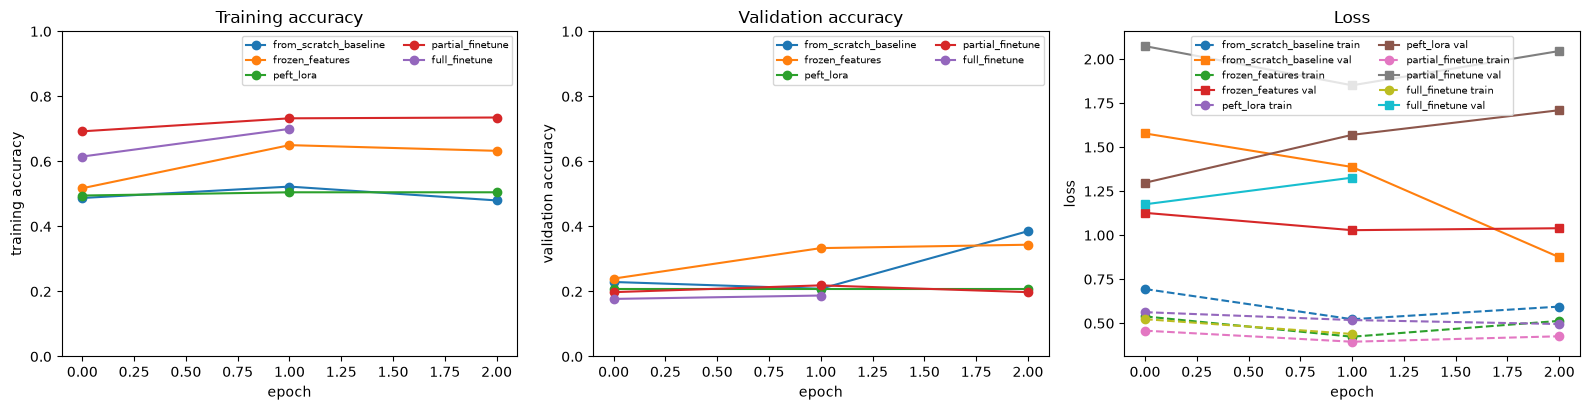

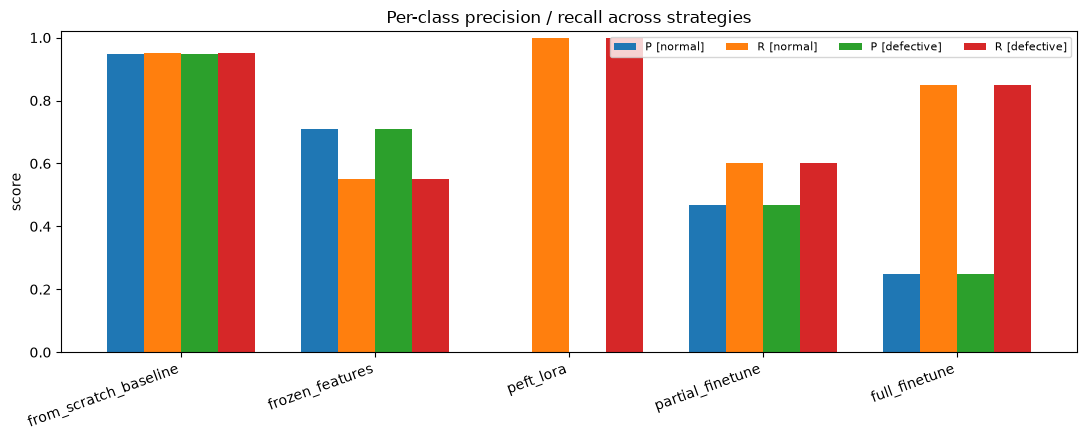

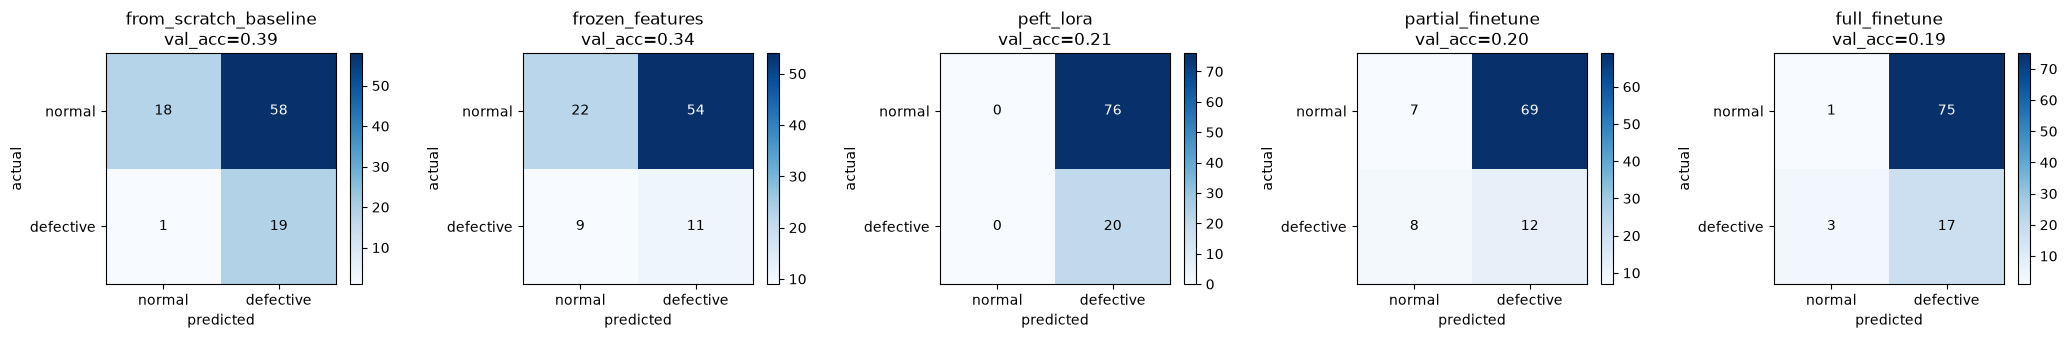

In [ ]:
# === Training curves: train-acc / val-acc / loss per variant (FR-16) ============
order = sorted(results, key=lambda n: evals[n]["val_acc"], reverse=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for name in order:
    h = results[name]["history"]
    axes[0].plot(h["train_acc"], marker="o", label=name)
    axes[1].plot(h["val_acc"], marker="o", label=name)
    axes[2].plot(h["train_loss"], ls="--", marker="o", label=f"{name} train")
    axes[2].plot(h["val_loss"], ls="-", marker="s", label=f"{name} val")
for ax, title in zip(axes, ["Training accuracy", "Validation accuracy", "Loss"]):
    ax.set_xlabel("epoch"); ax.set_ylabel(title.lower()); ax.set_title(title)
    ax.legend(fontsize=7, ncol=2)
axes[0].set_ylim(0, 1); axes[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()


# === Grouped per-class precision/recall (FR-21) ===================================
series = [
    (f"P [{CLASS_NAMES[0]}]", lambda e, i: e["precision"][i]),
    (f"R [{CLASS_NAMES[0]}]", lambda e, i: e["recall"][i]),
    (f"P [{CLASS_NAMES[1]}]", lambda e, i: e["precision"][i]),
    (f"R [{CLASS_NAMES[1]}]", lambda e, i: e["recall"][i]),
]
fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(order)); width = 0.19
for j, (label, fn) in enumerate(series):
    vals = [fn(evals[n], j % 2) for n in order]
    ax.bar(x + (j - 1.5) * width, vals, width, label=label)
ax.set_xticks(x); ax.set_xticklabels(order, rotation=20, ha="right")
ax.set_ylabel("score"); ax.set_ylim(0, 1.02)
ax.set_title("Per-class precision / recall across strategies")
ax.legend(ncol=4, fontsize=8)
plt.tight_layout(); plt.show()

# --- Confusion matrices per variant (FR-21) -------------------------------------
fig, axes = plt.subplots(1, len(order), figsize=(4.2 * len(order), 3.4))
axes = np.atleast_1d(axes)                      # robust to a single variant
for ax, name in zip(axes, order):
    cm = evals[name]["cm"]
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{name}\nval_acc={evals[name]['val_acc']:.2f}")
    ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASS_NAMES)
    ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("predicted"); ax.set_ylabel("actual")
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()


In [ ]:
# === Consolidated summary DataFrame (accuracy, P/R, overfit gap) (FR-21) ========
summary_rows = []
for name, e in evals.items():
    summary_rows.append({
        "variant": name,
        "val_acc": e["val_acc"],
        "overfit_gap": e["overfit_gap"],
        f"precision_{CLASS_NAMES[0]}": e["precision"][0],
        f"recall_{CLASS_NAMES[0]}": e["recall"][0],
        f"precision_{CLASS_NAMES[1]}": e["precision"][1],
        f"recall_{CLASS_NAMES[1]}": e["recall"][1],
    })
final_df = pd.DataFrame(summary_rows).sort_values("val_acc", ascending=False)
for col in [f"precision_{c}" for c in CLASS_NAMES] + \
           [f"recall_{c}" for c in CLASS_NAMES]:
    final_df[col] = final_df[col].round(3)
final_df["val_acc"] = final_df["val_acc"].round(3)
final_df["overfit_gap"] = final_df["overfit_gap"].round(3)
final_df


,variant,val_acc,overfit_gap,precision_normal,recall_normal,precision_defective,recall_defective
3,from_scratch_baseline,0.385,0.095,0.947,0.237,0.247,0.95
0,frozen_features,0.344,0.289,0.710,0.289,0.169,0.55
2,peft_lora,0.208,0.297,0.000,0.000,0.208,1.00
1,partial_finetune,0.198,0.537,0.467,0.092,0.148,0.60
4,full_finetune,0.188,0.512,0.250,0.013,0.185,0.85


### 🎛️ Interactive experiment & the `custom` benchmark row

Run any variant at your own LR/epochs to build intuition. The resulting
evaluation is registered into the **hardcoded `custom` registry row** shown in
the final summary — so you can compare *your* quick run against the full 5-way
run. If widgets are missing, call `run_interactive_experiment(...)` directly.


In [ ]:
# === Interactive experiment -> fills the immutable `custom` row (FR-20) =========
CUSTOM_BENCHMARK: Dict[str, Optional[dict]] = {"registered": False}

def run_interactive_experiment(strategy="frozen_features", lr=1e-3, epochs=2):
    """Train one variant quickly, evaluate, and register it as the `custom` row."""
    assert strategy in VARIANTS, f"unknown strategy {strategy}"
    set_seed()
    model = VARIANTS[strategy]().to(DEVICE)
    optimizer = make_optimizer(model, lr)
    print(f"Running '{strategy}' for {epochs} epoch(s) at lr={lr} ...")
    _, history = train_model(model, optimizer, epochs, label=strategy)

    preds, targets = predict(model, val_loader)
    prec, rec, f1, _ = precision_recall_fscore_support(
        targets, preds, labels=list(range(NUM_CLASSES)), zero_division=0)
    val_acc = float((preds == targets).mean())
    train_acc = history["train_acc"][-1]
    row = {
        "variant": "custom",
        "val_acc": val_acc,
        "overfit_gap": train_acc - val_acc,
        f"precision_{CLASS_NAMES[0]}": prec[0],
        f"recall_{CLASS_NAMES[0]}": rec[0],
        f"precision_{CLASS_NAMES[1]}": prec[1],
        f"recall_{CLASS_NAMES[1]}": rec[1],
    }
    CUSTOM_BENCHMARK["registered"] = True
    CUSTOM_BENCHMARK["row"] = row
    print("Registered `custom` row:", {k: round(v, 3) if isinstance(v, float) else v
                                       for k, v in row.items()})

    # quick learning curve
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(history["train_acc"], label="train", marker="o")
    ax.plot(history["val_acc"], label="val", marker="o")
    ax.set_xlabel("epoch"); ax.set_ylabel("accuracy")
    ax.set_title(f"custom: {strategy} (lr={lr})"); ax.legend()
    plt.tight_layout(); plt.show()
    return row


if WIDGETS_AVAILABLE:
    _dd = widgets.Dropdown(options=list(VARIANTS), value="frozen_features",
                           description="Strategy:")
    _lr = widgets.FloatLogSlider(value=1e-3, base=10, min=-5, max=-1, step=0.5,
                                 description="LR:")
    _ep = widgets.IntSlider(value=2, min=1, max=5, description="Epochs:")
    _btn = widgets.Button(description="Run experiment")
    _out = widgets.Output()

    def _on_click(_):
        with _out:
            _out.clear_output()
            run_interactive_experiment(_dd.value, _lr.value, _ep.value)
    _btn.on_click(_on_click)
    display(widgets.VBox([_dd, _lr, _ep, _btn, _out]))
else:
    print("ipywidgets unavailable — call run_interactive_experiment(...) directly, e.g.:")
    print('  run_interactive_experiment("frozen_features", lr=1e-3, epochs=2)')


### Task Relatedness Experiment — negative-transfer sanity (per §15/§16)

We compare each transfer strategy against the **from-scratch baseline**:

- **Case A (related):** transfer strategies should help (higher val_acc).
- **Case B (unrelated):** transfer can *hurt* → **negative transfer**.

The sanity block below prints, for each variant, the **delta** in validation
accuracy and in minority-class recall relative to the baseline, and flags any
variant that underperforms it. Then we reflect on *why* that could happen.


In [ ]:
# === Negative-transfer sanity: transfer variants vs from-scratch baseline =======
base = evals.get("from_scratch_baseline")
if base is None:
    print("Baseline missing — run the training + eval cells first.")
else:
    print(f"Baseline from_scratch_baseline: val_acc={base['val_acc']:.3f} "
          f"defective_recall={base['recall'][1]:.3f}")
    print("\nDelta vs baseline (positive = transfer helps):")
    for name, e in evals.items():
        if name == "from_scratch_baseline":
            continue
        d_acc = e["val_acc"] - base["val_acc"]
        d_rec = e["recall"][1] - base["recall"][1]
        warn = "  ⚠️ NEGATIVE transfer?" if d_acc < -0.01 else ""
        print(f"  {name:<24s} delta_acc={d_acc:+.3f} "
              f"delta_defective_recall={d_rec:+.3f}{warn}")
print("\nNow answer: does any transfer strategy lose to the baseline? If so, is it")
print("domain shift, distribution shift, or a too-small dataset? (Sections 15/16)")


Baseline from_scratch_baseline: val_acc=0.385 defective_recall=0.950

Delta vs baseline (positive = transfer helps):
  frozen_features          delta_acc=-0.042 delta_defective_recall=-0.400  ⚠️ NEGATIVE transfer?
  partial_finetune         delta_acc=-0.188 delta_defective_recall=-0.350  ⚠️ NEGATIVE transfer?
  peft_lora                delta_acc=-0.177 delta_defective_recall=+0.050  ⚠️ NEGATIVE transfer?
  full_finetune            delta_acc=-0.198 delta_defective_recall=-0.100  ⚠️ NEGATIVE transfer?

Now answer: does any transfer strategy lose to the baseline? If so, is it
domain shift, distribution shift, or a too-small dataset? (Sections 15/16)


### Reflection — when would transfer fail?

- **Domain shift** (e.g. microscopy or medical imaging): pretrained features were
  tuned to natural photos; textures/stats differ → transfer gains shrink or turn
  negative.
- **Too-small / noisy dataset:** even a good prior cannot generalize from a
  handful of images.
- **Very different output space:** if the target classes are semantically far
  from ImageNet's, the late features are less useful.
- **Distribution shift:** the label/feature relationship differs (e.g. defects
  look nothing like everyday objects).

The fix is often **data-centric**: more/cleaner data, domain-specific
pre-training, or choosing how many layers to freeze based on relatedness.


## Measured-Cost Report (FR-22 — not a spec §, implementation section)

Everything below is **measured on this machine's run** (wall-clock, per-variant
train time, images/s throughput, peak RSS, artifact size, actual-vs-estimated
epoch cost), not hand-waving — FR-22.

If the full training pipeline hasn't run in this kernel, the cell prints a clear
notice instead of failing (standalone-friendly).


In [ ]:
# === END-OF-RUN SUMMARY: measured computational cost (standalone-friendly) ======
def _fmt_duration(seconds):
    m, s = divmod(int(round(float(seconds))), 60)
    return f"{m}:{s:02d}"

print("=" * 70)
print("END-OF-RUN COMPUTATIONAL COST REPORT")
print("=" * 70)

# Total wall-clock (only meaningful if the setup cell ran in THIS kernel).
try:
    total_wall_s = time.perf_counter() - START_WALL
    print(f"\nTotal wall-clock (setup -> this cell): {total_wall_s:.1f} s "
          f"({_fmt_duration(total_wall_s)})")
except NameError:
    total_wall_s = None
    print("\nTotal wall-clock: N/A (setup did not run in this kernel).")

# Pipeline-not-run notice.
missing = [n for n in ("results", "evals", "COST_EST") if n not in globals()]
if missing or "results" not in globals() or not results:
    print(f"\n⚠️ No training results available ({', '.join(missing) or 'results empty'}).")
    print("   Run the full pipeline (Sections 14–16) in this kernel first, then")
    print("   re-run this cell for the measured cost report.")
else:
    rows = []
    for name, r in results.items():
        h = r["history"]
        train_time = r["train_time_s"]
        rows.append({
            "variant": name,
            "train_time_s": train_time,
            "train_time_per_epoch_s": r["train_time_per_epoch_s"],
            "train_throughput_img_s": float(np.mean(
                h["train_throughput_img_s"] or [0.0])),
            "peak_rss_mb": r["peak_rss_mb"],
            "artifact_mb": r["artifact_mb"],
            "val_acc": evals[name]["val_acc"],
            "est_sec_per_epoch": COST_EST[name]["sec_per_epoch"],
        })

    report = pd.DataFrame(rows).sort_values("val_acc", ascending=False)
    print("\n--- Per-variant measured cost ---")
    print(report[["variant", "train_time_s", "train_time_per_epoch_s",
                  "train_throughput_img_s", "peak_rss_mb", "artifact_mb"]]
          .to_string(index=False, float_format=lambda x: f"{x:.2f}"))

    total_train = sum(r["train_time_s"] for r in results.values())
    print(f"\nSum of training time: {total_train:.1f} s "
          f"({_fmt_duration(total_train)})")

    print("\n--- Actual vs estimated seconds/epoch (FR-22) ---")
    cmp = report[["variant", "train_time_per_epoch_s", "est_sec_per_epoch"]].copy()
    cmp["diff%"] = (cmp["train_time_per_epoch_s"] /
                    cmp["est_sec_per_epoch"].replace(0, float("nan")) - 1.0) * 100.0
    print(cmp.to_string(index=False, float_format=lambda x: f"{x:.1f}"))

    print("\n--- Accuracy / per-class P-R (incl. custom row if registered) ---")
    acc_rows = [{"variant": n,
                 "val_acc": e["val_acc"],
                 f"precision_{CLASS_NAMES[0]}": e["precision"][0],
                 f"recall_{CLASS_NAMES[0]}": e["recall"][0],
                 f"precision_{CLASS_NAMES[1]}": e["precision"][1],
                 f"recall_{CLASS_NAMES[1]}": e["recall"][1]}
                for n, e in evals.items()]
    if CUSTOM_BENCHMARK.get("registered"):
        acc_rows.append(CUSTOM_BENCHMARK["row"])
    acc_df = pd.DataFrame(acc_rows).sort_values("val_acc", ascending=False)
    for c in acc_df.columns:
        if c != "variant":
            acc_df[c] = acc_df[c].round(3)
    print(acc_df.to_string(index=False))

    if total_wall_s is not None:
        print(f"\nWall time incl. training: {total_wall_s:.1f} s "
              f"({_fmt_duration(total_wall_s)}) | training only: "
              f"{total_train:.1f} s ({_fmt_duration(total_train)})")

print("\nDone.")


END-OF-RUN COMPUTATIONAL COST REPORT

Total wall-clock (setup -> this cell): 810.0 s (13:30)

--- Per-variant measured cost ---
              variant  train_time_s  train_time_per_epoch_s  train_throughput_img_s  peak_rss_mb  artifact_mb
from_scratch_baseline        158.74                   52.91                    8.28       960.93        42.71
      frozen_features        114.07                   38.02                   12.72       827.77        42.71
            peft_lora        115.40                   38.47                   13.50       744.43        42.73
     partial_finetune        239.06                   79.69                    7.39       748.18        42.71
        full_finetune        121.17                   60.58                    7.00      1021.06        42.71

Sum of training time: 748.4 s (12:28)

--- Actual vs estimated seconds/epoch (FR-22) ---
              variant  train_time_per_epoch_s  est_sec_per_epoch  diff%
from_scratch_baseline                    52.9     

## Section 17 — Conclusions (Mental Model)

### The complete mental model

```text
Knowledge → Pretraining → Learn Generic Features
     ↓
Reuse Features → Adapt Network → Freeze or Fine-tune
     ↓
Evaluate → Analyze Task Similarity
```

Transfer learning succeeds because **many machine learning tasks share useful
lower-level representations**. We proved it empirically: five strategies, one
shared loop, real images, measured costs.

### Per-section takeaways (quick recap)

1. **Motivation:** training from scratch needs data/resources/time we often lack.
2. **Definition:** reuse a learned representation across a source → target gap.
3. **Assumptions:** feature transferability + data asymmetry + task relatedness.
4. **Pretraining:** Option A (reuse public weights) vs Option B (train your own).
5. **Source task:** ImageNet taught the model *how to see*, not what classes mean.
6. **Target task:** small, imbalanced defect detection — textbook TL scenario.
7. **Feature reuse:** we reuse the feature extractor, not predictions.
8. **Network modification:** swap the 1000-way head for a 2-way head.
9. **Freeze layers:** feature extraction = only the head learns (safest on small data).
10. **Fine-tuning:** partial (layer4+head) balances; full adapts everything (risky).
11. **PEFT:** LoRA = low-rank delta, tiny trainable set, preserves the base.
12. **Relatedness:** domain/distribution shift can cause negative transfer.
13. **Experiments:** measured comparison of 5 strategies with curves and metrics.

### Final validation checklist

- ✅ Current weights API (`ResNet18_Weights.DEFAULT`) — no `pretrained=True`.
- ✅ Five variants, fresh seeded isolated models, per-variant LR + epochs.
- ✅ Weighted CE + WeightedRandomSampler for the 80/20 imbalance.
- ✅ Per-class precision/recall with `zero_division=0` (single-class safe).
- ✅ Measured wall-clock, train time, throughput, peak RSS, artifact size.
- ✅ Dataset resolution + empty-only auto-download of real images (never overwrite).


## Learning Outcome — the 11 questions (§ spec expected outcome)

Tick the ones you can answer **now**:

1. What is transfer learning?
2. What exactly is transferred?
3. Why are pretrained models useful?
4. Why are source and target tasks different?
5. Why are features reusable?
6. When should layers be frozen?
7. When should the entire model be fine-tuned?
8. What is PEFT, and why does it save memory?
9. Why is task relatedness important?
10. What causes negative transfer?
11. How does the complete workflow operate, from pretraining to deployment?

If any answer is fuzzy, re-read the matching section — the notebook is designed so
every implementation sits right below the concept it teaches.

**You have finished this spec-driven transfer learning notebook. 🎉** Bonus: run
the interactive experiment (your own LR/epochs) and re-run the Summary cell to
include your `custom` benchmark row.
